In [1]:
# 0) Mount Drive (skip if already mounted)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# 1) Use your exact path
import os, pandas as pd

PATH = "/content/drive/MyDrive/traffic_data/dhaka_timeseries_2025-02-15_7d_15min.csv"  # <-- your file
assert os.path.exists(PATH), f"File not found: {PATH}"

# (Optional) quick peek without loading everything
print("OK, found file:", PATH)
print("First 3 rows:")
print(pd.read_csv(PATH, compression="infer", nrows=3))


OK, found file: /content/drive/MyDrive/traffic_data/dhaka_timeseries_2025-02-15_7d_15min.csv
First 3 rows:
                   timestamp           u           v  key     road_type  \
0  2025-02-15T00:00:00+06:00  7858277362  7858277421    0  unclassified   
1  2025-02-15T00:00:00+06:00  5017920339  5017920343    0   residential   
2  2025-02-15T00:00:00+06:00  9902261157  9902261208    1   residential   

   length_m  free_speed_kmh  traffic_factor  current_speed_kmh  \
0    98.208            20.0          0.0500              19.20   
1   322.910            15.0          0.3329              11.01   
2   224.443            15.0          0.2272              12.27   

   travel_time_seconds  
0                18.41  
1               105.63  
2                65.83  


In [3]:
# =========================
# 0) CONFIG  (fixed path)
# =========================
import os, glob, json, gc, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from collections import defaultdict

torch.set_num_threads(max(1, os.cpu_count()//2))
RNG = np.random.default_rng(42)
random.seed(42)

# Your exact file:
PATH = "/content/drive/MyDrive/traffic_data/dhaka_timeseries_2025-02-15_7d_15min.csv"
assert os.path.exists(PATH), f"File not found: {PATH}"
print("Using:", PATH)

FREQ = "15min"
MAX_EDGES = 1200          # reduce to ~600 if RAM is tight; increase if you have more RAM
LOOKBACK = 12             # 3 hours
HORIZON = 1               # 1-step ahead (15 min) for simplicity & plotting
BATCH_SIZE = 32
EPOCHS = 4                # quick demo
LR = 1e-3
WEIGHT_DECAY = 1e-5


Using: /content/drive/MyDrive/traffic_data/dhaka_timeseries_2025-02-15_7d_15min.csv


Pass 1: discover unique edges ...
Unique edges in file: 12,000
Pass 2: load only sampled edges ...
Y shape (T×N): (672, 1200)
Edge connections (line-graph approx): 38
A_norm nnz: 1236
Batches: train (458, 12, 1200) val (89, 12, 1200) test (89, 12, 1200)

Training ...
ep01  train_MAE:0.8845  val_MAE:0.7407
ep02  train_MAE:0.5731  val_MAE:0.4287
ep03  train_MAE:0.4154  val_MAE:0.3788
ep04  train_MAE:0.3895  val_MAE:0.3701


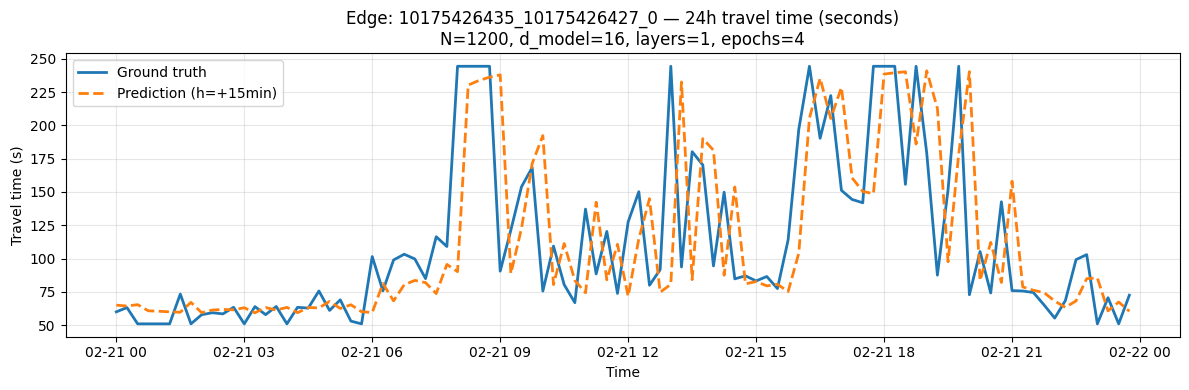

In [4]:
# =========================
# 1) Efficient data loading
#    (two-pass chunked read to cap edges)
# =========================
usecols_base = ["timestamp","u","v","key"]
usecols_all  = ["timestamp","u","v","key","travel_time_seconds","length_m","free_speed_kmh"]

print("Pass 1: discover unique edges ...")
edge_counts = defaultdict(int)
for chunk in pd.read_csv(PATH, compression="infer", usecols=usecols_base, chunksize=400_000, parse_dates=["timestamp"]):
    eid = (chunk["u"].astype(str)+"_"+chunk["v"].astype(str)+"_"+chunk["key"].astype(str)).to_numpy()
    for e in np.unique(eid):
        edge_counts[e] += 1

unique_edges = list(edge_counts.keys())
print(f"Unique edges in file: {len(unique_edges):,}")

if len(unique_edges) > MAX_EDGES:
    sampled_edges = RNG.choice(unique_edges, size=MAX_EDGES, replace=False)
else:
    sampled_edges = np.array(unique_edges)
sampled_edges_set = set(sampled_edges)

print("Pass 2: load only sampled edges ...")
parts = []
for chunk in pd.read_csv(PATH, compression="infer", usecols=usecols_all, chunksize=200_000, parse_dates=["timestamp"]):
    chunk["edge_id"] = chunk["u"].astype(str)+"_"+chunk["v"].astype(str)+"_"+chunk["key"].astype(str)
    mask = chunk["edge_id"].isin(sampled_edges_set)
    if mask.any():
        parts.append(chunk.loc[mask, ["timestamp","edge_id","travel_time_seconds","length_m","free_speed_kmh","u","v","key"]])

df = pd.concat(parts, ignore_index=True)
del parts; gc.collect()
assert len(df) > 0, "No rows loaded—check the file and sampled edges."

# =========================
# 2) Pivot to Y[T×N] and basic fills
# =========================
df["timestamp"] = pd.to_datetime(df["timestamp"])
ts_min, ts_max = df["timestamp"].min(), df["timestamp"].max()
ti = pd.date_range(start=ts_min, end=ts_max, freq=FREQ)

free = (df.drop_duplicates("edge_id")
          .set_index("edge_id")[["length_m","free_speed_kmh"]])
free["free_time_s"] = free["length_m"] / (free["free_speed_kmh"] * 1000/3600)

Y = (df.pivot_table(index="timestamp", columns="edge_id", values="travel_time_seconds")
       .reindex(ti).sort_index())

Y = Y.reindex(columns=free.index, fill_value=np.nan)
Y = Y.ffill().fillna(free["free_time_s"]).astype("float32")

edge_cols = list(Y.columns)
N = len(edge_cols)
T = len(Y)
print("Y shape (T×N):", Y.shape)

# =========================
# 3) Build a light adjacency on edges (line-graph approx)
# =========================
meta = df.drop_duplicates("edge_id").set_index("edge_id")[["u","v","key"]].reindex(edge_cols)
node_to_edges = defaultdict(list)
for idx, (eid, row) in enumerate(meta.iterrows()):
    node_to_edges[row["u"]].append(idx)
    node_to_edges[row["v"]].append(idx)

pairs = []
for edges_at_node in node_to_edges.values():
    if len(edges_at_node) < 2:
        continue
    edges_at_node.sort()
    for i in range(len(edges_at_node)-1):
        a = edges_at_node[i]; b = edges_at_node[i+1]
        pairs.append((a,b)); pairs.append((b,a))

pairs = np.array(pairs, dtype=np.int64).T if len(pairs)>0 else np.empty((2,0), dtype=np.int64)
print("Edge connections (line-graph approx):", pairs.shape[1])

# =========================
# 4) Precompute sparse normalized adjacency A_norm
# =========================
def precompute_A_norm(edge_index, N, device="cpu", dtype=torch.float32):
    edge_index = torch.as_tensor(edge_index, dtype=torch.long, device=device)
    if edge_index.numel() == 0:
        idx = torch.arange(N, device=device)
        vals = torch.ones(N, dtype=dtype, device=device)
        return torch.sparse_coo_tensor(torch.stack([idx, idx]), vals, (N, N), device=device).coalesce()

    vals = torch.ones(edge_index.size(1), dtype=dtype, device=device)
    A = torch.sparse_coo_tensor(edge_index, vals, (N, N), device=device).coalesce()
    idx = torch.arange(N, device=device)
    I = torch.sparse_coo_tensor(torch.stack([idx, idx]),
                                torch.ones(N, dtype=dtype, device=device),
                                (N, N), device=device).coalesce()
    A_hat = (A + I).coalesce()
    deg = torch.sparse.sum(A_hat, dim=1).to_dense().clamp(min=1.0)
    d_inv_sqrt = deg.pow(-0.5)
    r, c = A_hat.indices()
    v = A_hat.values() * d_inv_sqrt[r] * d_inv_sqrt[c]
    return torch.sparse_coo_tensor(torch.stack([r, c]), v, (N, N), device=device).coalesce()

edge_index_t = torch.as_tensor(pairs, dtype=torch.long)
A_norm_sparse = precompute_A_norm(edge_index_t, N, device="cpu", dtype=torch.float32)
print("A_norm nnz:", A_norm_sparse._nnz())

# =========================
# 5) Normalize, split, and make windows
# =========================
y_mean = Y.mean(axis=0).astype("float32")
y_std  = Y.std(axis=0).replace(0, 1).astype("float32")
Yz = ((Y - y_mean)/y_std).astype("float32")

t_train, t_val = int(0.70*T), int(0.85*T)
Ytr, Yva, Yte = Yz.iloc[:t_train], Yz.iloc[t_train:t_val], Yz.iloc[t_val:]

def make_windows(Yblock, L, H):
    arr = Yblock.to_numpy()
    Xs, Ys = [], []
    for t0 in range(L, len(arr)-H+1):
        Xs.append(arr[t0-L:t0, :])
        Ys.append(arr[t0:t0+H, :])
    return np.stack(Xs), np.stack(Ys)

LOOKBACK = 12
HORIZON  = 1
Xtr, Ytr_out = make_windows(Ytr, LOOKBACK, HORIZON)
Xva, Yva_out = make_windows(Yva, LOOKBACK, HORIZON)
Xte, Yte_out = make_windows(Yte, LOOKBACK, HORIZON)
print("Batches:", "train", Xtr.shape, "val", Xva.shape, "test", Xte.shape)

def to_torch(X, Y):
    X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # [B,1,L,N]
    Y = torch.tensor(Y, dtype=torch.float32)               # [B,H,N]
    return X, Y

BATCH_SIZE = 32
Xtr_t, Ytr_t = to_torch(Xtr, Ytr_out)
Xva_t, Yva_t = to_torch(Xva, Yva_out)
Xte_t, Yte_t = to_torch(Xte, Yte_out)
train_loader = DataLoader(TensorDataset(Xtr_t, Ytr_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xva_t, Yva_t), batch_size=BATCH_SIZE, shuffle=False)

# =========================
# 6) Tiny ST model (Transformer + cached sparse GCN)
# =========================
class SimpleGCNConvCached(nn.Module):
    def __init__(self, in_dim, out_dim, A_norm_sparse, bias=True):
        super().__init__()
        assert A_norm_sparse.is_sparse
        self.lin = nn.Linear(in_dim, out_dim, bias=bias)
        self.N = A_norm_sparse.size(0)
        self.register_buffer("A_idx", A_norm_sparse.indices())
        self.register_buffer("A_val", A_norm_sparse.values())
    def forward(self, x):  # x: [B, N, C]
        if x.dim() == 2: x = x.unsqueeze(0)
        B, N, _ = x.shape
        assert N == self.N
        A = torch.sparse_coo_tensor(self.A_idx, self.A_val, (N, N), device=x.device)
        Xw = self.lin(x)
        outs = [torch.sparse.mm(A, Xw[b]) for b in range(B)]
        return torch.stack(outs, 0)

class STTiny(nn.Module):
    def __init__(self, lookback, horizon, n_nodes, A_norm_sparse,
                 d_model=16, nhead=2, nlayers=1):
        super().__init__()
        self.L, self.H, self.N = lookback, horizon, n_nodes
        self.inp = nn.Linear(1, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            batch_first=True, dropout=0.1, activation="gelu"
        )
        self.enc = nn.TransformerEncoder(enc_layer, nlayers)
        self.gmix = SimpleGCNConvCached(d_model, d_model, A_norm_sparse)
        self.head = nn.Linear(d_model, horizon)
    def forward(self, x):                      # x: [B,1,L,N]
        B, C, L, N = x.shape
        assert C==1 and L==self.L and N==self.N
        z = self.inp(x.permute(0,3,2,1).reshape(B*N, L, 1))
        z = self.enc(z)
        z_last = z[:, -1, :].view(B, N, -1)
        z_g = self.gmix(z_last)
        y = self.head(z_g)
        return y.permute(0,2,1)               # [B,H,N]

device = torch.device("cpu")
EPOCHS = 4
model = STTiny(LOOKBACK, HORIZON, N, A_norm_sparse, d_model=16, nhead=2, nlayers=1).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.L1Loss()

# =========================
# 7) Quick training loop
# =========================
def run_epoch(loader, train=True):
    model.train(train)
    tot, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        with torch.set_grad_enabled(train):
            pred = model(xb)
            loss = loss_fn(pred, yb)
        if train:
            opt.zero_grad(); loss.backward(); opt.step()
        bs = xb.size(0); tot += loss.item()*bs; n += bs
    return tot/max(n,1)

print("\nTraining ...")
best = float("inf"); best_state = None
for ep in range(EPOCHS):
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    print(f"ep{ep+1:02d}  train_MAE:{tr:.4f}  val_MAE:{va:.4f}")
    if va < best - 1e-4:
        best = va
        best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
if best_state is not None:
    model.load_state_dict(best_state)

# =========================
# 8) Visualization: 1 edge, guaranteed 24-hour window
# =========================
import random
edge_idx = random.randrange(N)
edge_name = edge_cols[edge_idx]

steps_per_day = int(pd.Timedelta("1D")/pd.Timedelta(FREQ))

def pick_start_for_24h(t_begin, t_end, lookback, steps):
    """Return a start index that fits [lookback + steps] between t_begin..t_end.
       If not possible, fallback to last full day in the entire series."""
    if (t_end - t_begin) >= (lookback + steps):
        return t_begin + lookback                  # inside the split
    # fallback: anywhere in the global series
    return max(lookback, T - steps)

start_24 = pick_start_for_24h(t_val, T, LOOKBACK, steps_per_day)
end_24   = start_24 + steps_per_day
time_idx = Yz.index[start_24:end_24]
# no assert needed now: time_idx is guaranteed to be 24h long

Yz_np = Yz.to_numpy(dtype=np.float32)
preds = []
for tcur in range(start_24, end_24):
    xwin = Yz_np[tcur-LOOKBACK:tcur, :]
    xwin = torch.tensor(xwin, dtype=torch.float32).unsqueeze(0).unsqueeze(1)
    with torch.no_grad():
        yhat = model(xwin).cpu().numpy()[0, 0, :]
    preds.append(yhat[edge_idx])

preds = np.array(preds)                                # [96]
true_vals = Yz_np[start_24:end_24, edge_idx]           # [96]



# Denormalize to seconds for readability
mean_e = float(y_mean.iloc[edge_idx])
std_e  = float(y_std.iloc[edge_idx]) if float(y_std.iloc[edge_idx]) != 0.0 else 1.0

preds = np.asarray(preds)                 # [steps]
true_vals = np.asarray(true_vals)         # [steps]

pred_sec = preds * std_e + mean_e         # model predictions in seconds
true_sec = true_vals * std_e + mean_e     # ground truth in seconds

# (Optional sanity check)
# print(len(time_idx), len(pred_sec), len(true_sec))

from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_regression_metrics(y_true, y_pred, prefix=""):
    """
    y_true, y_pred: 1D or flat arrays (e.g. 24h series for 1 edge)
    Prints and returns MAE, RMSE, MAPE in original units (seconds).
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)

    # RMSE = sqrt(MSE)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    # MAPE: percentage error (safe against 0 by adding epsilon)
    eps = 1e-3
    mape = np.mean(
        np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))
    ) * 100.0

    print(f"{prefix}MAE : {mae:.4f} s")
    print(f"{prefix}RMSE: {rmse:.4f} s")
    print(f"{prefix}MAPE: {mape:.2f}%")

    return mae, rmse, mape


# =========================
# 9) Plot
# =========================
plt.figure(figsize=(12,4))
plt.plot(time_idx, true_sec, lw=2, label="Ground truth")
plt.plot(time_idx, pred_sec, lw=2, ls="--", label="Prediction (h=+15min)")
plt.title(f"Edge: {edge_name} — 24h travel time (seconds)\n"
          f"N={N}, d_model=16, layers=1, epochs={EPOCHS}")
plt.xlabel("Time"); plt.ylabel("Travel time (s)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()



Pass 1: discover unique edges ...
Unique edges in file: 12,000
Pass 2: load only sampled edges ...
Y shape (T×N): (672, 1200)
Edge connections (line-graph approx): 38
A_norm nnz: 1236
Batches: train (458, 12, 1200) val (89, 12, 1200) test (89, 12, 1200)

Training ...
ep01  train_MAE:0.7340  val_MAE:0.5016
ep02  train_MAE:0.4327  val_MAE:0.3893
ep03  train_MAE:0.3982  val_MAE:0.3722
ep04  train_MAE:0.3834  val_MAE:0.3614

Global test metrics (all edges, all test windows):
MAE : 30.5273 s
RMSE: 86.7077 s
MAPE: 29.70%
24h edge | MAE : 64.3017 s
24h edge | RMSE: 101.7268 s
24h edge | MAPE: 36.04%


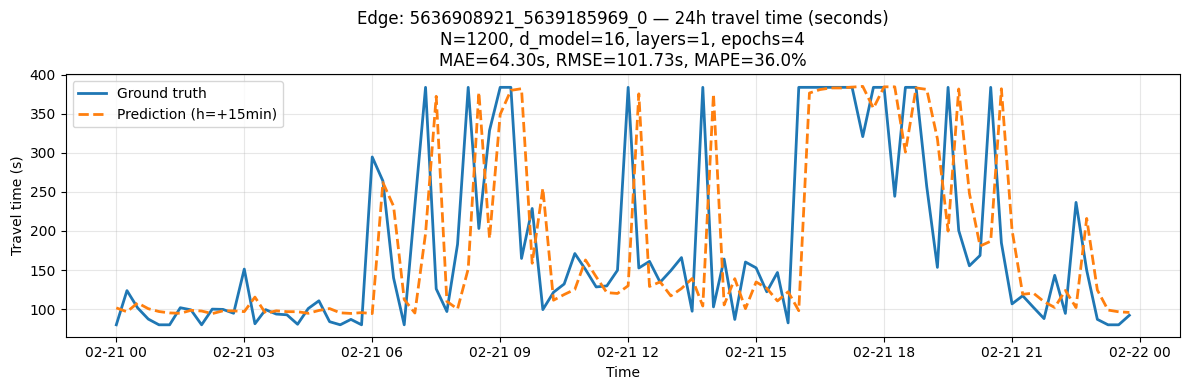

In [5]:
# ============================================
# Full ST GNN+Transformer baseline + metrics
# ============================================

import gc
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------
# Config
# -------------------------
PATH = "/content/drive/MyDrive/traffic_data/dhaka_timeseries_2025-02-15_7d_15min.csv"  # change if needed (.csv or .csv.gz both ok)
FREQ = "15min"
MAX_EDGES = 1200          # cap edges for speed; increase if you want
RNG = np.random.default_rng(42)

device = torch.device("cpu")  # keep CPU for simplicity; can switch to cuda later if you fix A_norm device logic

# =========================
# Metric helper
# =========================
def compute_regression_metrics(y_true, y_pred, prefix=""):
    """
    y_true, y_pred: flat arrays in original units (seconds)
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    eps = 1e-3
    mape = np.mean(
        np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))
    ) * 100.0

    print(f"{prefix}MAE : {mae:.4f} s")
    print(f"{prefix}RMSE: {rmse:.4f} s")
    print(f"{prefix}MAPE: {mape:.2f}%")

    return mae, rmse, mape


# =========================
# 1) Efficient data loading
#    (two-pass chunked read to cap edges)
# =========================
usecols_base = ["timestamp", "u", "v", "key"]
usecols_all  = ["timestamp", "u", "v", "key", "travel_time_seconds", "length_m", "free_speed_kmh"]

print("Pass 1: discover unique edges ...")
edge_counts = defaultdict(int)
for chunk in pd.read_csv(
    PATH,
    compression="infer",  # works for .csv and .csv.gz
    usecols=usecols_base,
    chunksize=400_000,
    parse_dates=["timestamp"],
):
    eid = (chunk["u"].astype(str) + "_" +
           chunk["v"].astype(str) + "_" +
           chunk["key"].astype(str)).to_numpy()
    for e in np.unique(eid):
        edge_counts[e] += 1

unique_edges = list(edge_counts.keys())
print(f"Unique edges in file: {len(unique_edges):,}")

if len(unique_edges) > MAX_EDGES:
    sampled_edges = RNG.choice(unique_edges, size=MAX_EDGES, replace=False)
else:
    sampled_edges = np.array(unique_edges)
sampled_edges_set = set(sampled_edges)

print("Pass 2: load only sampled edges ...")
parts = []
for chunk in pd.read_csv(
    PATH,
    compression="infer",
    usecols=usecols_all,
    chunksize=200_000,
    parse_dates=["timestamp"],
):
    chunk["edge_id"] = (chunk["u"].astype(str) + "_" +
                        chunk["v"].astype(str) + "_" +
                        chunk["key"].astype(str))
    mask = chunk["edge_id"].isin(sampled_edges_set)
    if mask.any():
        parts.append(chunk.loc[mask, ["timestamp", "edge_id",
                                      "travel_time_seconds",
                                      "length_m", "free_speed_kmh",
                                      "u", "v", "key"]])

df = pd.concat(parts, ignore_index=True)
del parts; gc.collect()
assert len(df) > 0, "No rows loaded—check the file and sampled edges."

# =========================
# 2) Pivot to Y[T×N] and basic fills
# =========================
df["timestamp"] = pd.to_datetime(df["timestamp"])
ts_min, ts_max = df["timestamp"].min(), df["timestamp"].max()
ti = pd.date_range(start=ts_min, end=ts_max, freq=FREQ)

free = (df.drop_duplicates("edge_id")
          .set_index("edge_id")[["length_m", "free_speed_kmh"]])
free["free_time_s"] = free["length_m"] / (free["free_speed_kmh"] * 1000 / 3600)

Y = (df.pivot_table(index="timestamp", columns="edge_id", values="travel_time_seconds")
       .reindex(ti).sort_index())

Y = Y.reindex(columns=free.index, fill_value=np.nan)
Y = Y.ffill().fillna(free["free_time_s"]).astype("float32")

edge_cols = list(Y.columns)
N = len(edge_cols)
T = len(Y)
print("Y shape (T×N):", Y.shape)

# =========================
# 3) Build a light adjacency on edges (line-graph approx)
# =========================
meta = (df.drop_duplicates("edge_id")
          .set_index("edge_id")[["u", "v", "key"]]
          .reindex(edge_cols))

node_to_edges = defaultdict(list)
for idx, (eid, row) in enumerate(meta.iterrows()):
    node_to_edges[row["u"]].append(idx)
    node_to_edges[row["v"]].append(idx)

pairs = []
for edges_at_node in node_to_edges.values():
    if len(edges_at_node) < 2:
        continue
    edges_at_node.sort()
    for i in range(len(edges_at_node) - 1):
        a = edges_at_node[i]; b = edges_at_node[i + 1]
        pairs.append((a, b)); pairs.append((b, a))

pairs = np.array(pairs, dtype=np.int64).T if len(pairs) > 0 else np.empty((2, 0), dtype=np.int64)
print("Edge connections (line-graph approx):", pairs.shape[1])

# =========================
# 4) Precompute sparse normalized adjacency A_norm
# =========================
def precompute_A_norm(edge_index, N, device="cpu", dtype=torch.float32):
    edge_index = torch.as_tensor(edge_index, dtype=torch.long, device=device)
    if edge_index.numel() == 0:
        idx = torch.arange(N, device=device)
        vals = torch.ones(N, dtype=dtype, device=device)
        return torch.sparse_coo_tensor(
            torch.stack([idx, idx]), vals, (N, N), device=device
        ).coalesce()

    vals = torch.ones(edge_index.size(1), dtype=dtype, device=device)
    A = torch.sparse_coo_tensor(edge_index, vals, (N, N), device=device).coalesce()

    idx = torch.arange(N, device=device)
    I = torch.sparse_coo_tensor(
        torch.stack([idx, idx]),
        torch.ones(N, dtype=dtype, device=device),
        (N, N), device=device
    ).coalesce()

    A_hat = (A + I).coalesce()
    deg = torch.sparse.sum(A_hat, dim=1).to_dense().clamp(min=1.0)
    d_inv_sqrt = deg.pow(-0.5)
    r, c = A_hat.indices()
    v = A_hat.values() * d_inv_sqrt[r] * d_inv_sqrt[c]
    return torch.sparse_coo_tensor(
        torch.stack([r, c]), v, (N, N), device=device
    ).coalesce()

edge_index_t = torch.as_tensor(pairs, dtype=torch.long)
A_norm_sparse = precompute_A_norm(edge_index_t, N, device="cpu", dtype=torch.float32)
print("A_norm nnz:", A_norm_sparse._nnz())

# =========================
# 5) Normalize, split, and make windows
# =========================
y_mean = Y.mean(axis=0).astype("float32")
y_std  = Y.std(axis=0).replace(0, 1).astype("float32")
Yz = ((Y - y_mean) / y_std).astype("float32")

t_train, t_val = int(0.70 * T), int(0.85 * T)
Ytr, Yva, Yte = Yz.iloc[:t_train], Yz.iloc[t_train:t_val], Yz.iloc[t_val:]

def make_windows(Yblock, L, H):
    arr = Yblock.to_numpy()
    Xs, Ys = [], []
    for t0 in range(L, len(arr) - H + 1):
        Xs.append(arr[t0 - L:t0, :])
        Ys.append(arr[t0:t0 + H, :])
    return np.stack(Xs), np.stack(Ys)

LOOKBACK = 12
HORIZON  = 1

Xtr, Ytr_out = make_windows(Ytr, LOOKBACK, HORIZON)
Xva, Yva_out = make_windows(Yva, LOOKBACK, HORIZON)
Xte, Yte_out = make_windows(Yte, LOOKBACK, HORIZON)
print("Batches:", "train", Xtr.shape, "val", Xva.shape, "test", Xte.shape)

def to_torch(X, Y):
    X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # [B,1,L,N]
    Y = torch.tensor(Y, dtype=torch.float32)               # [B,H,N]
    return X, Y

BATCH_SIZE = 32
Xtr_t, Ytr_t = to_torch(Xtr, Ytr_out)
Xva_t, Yva_t = to_torch(Xva, Yva_out)
Xte_t, Yte_t = to_torch(Xte, Yte_out)

train_loader = DataLoader(TensorDataset(Xtr_t, Ytr_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xva_t, Yva_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(Xte_t, Yte_t), batch_size=BATCH_SIZE, shuffle=False)

# =========================
# 6) Tiny ST model (Transformer + cached sparse GCN)
# =========================
class SimpleGCNConvCached(nn.Module):
    def __init__(self, in_dim, out_dim, A_norm_sparse, bias=True):
        super().__init__()
        assert A_norm_sparse.is_sparse
        self.lin = nn.Linear(in_dim, out_dim, bias=bias)
        self.N = A_norm_sparse.size(0)
        self.register_buffer("A_idx", A_norm_sparse.indices())
        self.register_buffer("A_val", A_norm_sparse.values())

    def forward(self, x):  # x: [B, N, C]
        if x.dim() == 2:
            x = x.unsqueeze(0)
        B, N, _ = x.shape
        assert N == self.N
        A = torch.sparse_coo_tensor(
            self.A_idx, self.A_val,
            (N, N), device=x.device
        )
        Xw = self.lin(x)
        outs = [torch.sparse.mm(A, Xw[b]) for b in range(B)]
        return torch.stack(outs, 0)

class STTiny(nn.Module):
    def __init__(self, lookback, horizon, n_nodes, A_norm_sparse,
                 d_model=16, nhead=2, nlayers=1):
        super().__init__()
        self.L, self.H, self.N = lookback, horizon, n_nodes
        self.inp = nn.Linear(1, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=4 * d_model,
            batch_first=True, dropout=0.1,
            activation="gelu"
        )
        self.enc = nn.TransformerEncoder(enc_layer, nlayers)
        self.gmix = SimpleGCNConvCached(d_model, d_model, A_norm_sparse)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):  # x: [B,1,L,N]
        B, C, L, N = x.shape
        assert C == 1 and L == self.L and N == self.N
        # [B,1,L,N] -> [B,N,L,1] -> [B*N,L,1]
        z = self.inp(x.permute(0, 3, 2, 1).reshape(B * N, L, 1))
        z = self.enc(z)
        z_last = z[:, -1, :].view(B, N, -1)   # [B,N,d_model]
        z_g = self.gmix(z_last)               # [B,N,d_model]
        y = self.head(z_g)                    # [B,N,H]
        return y.permute(0, 2, 1)            # [B,H,N]

EPOCHS = 4
model = STTiny(LOOKBACK, HORIZON, N, A_norm_sparse,
               d_model=16, nhead=2, nlayers=1).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.L1Loss()

# =========================
# 7) Training loop + global test metrics
# =========================
def run_epoch(loader, train=True):
    model.train(train)
    tot, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        with torch.set_grad_enabled(train):
            pred = model(xb)
            loss = loss_fn(pred, yb)
        if train:
            opt.zero_grad()
            loss.backward()
            opt.step()
        bs = xb.size(0); tot += loss.item() * bs; n += bs
    return tot / max(n, 1)

def evaluate_full_test(loader, y_mean, y_std):
    """
    Compute MAE/RMSE/MAPE over ALL test windows and ALL edges, in seconds.
    """
    model.eval()
    preds_all, true_all = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)          # [B,H,N]
            preds_all.append(pred.cpu().numpy())
            true_all.append(yb.cpu().numpy())

    preds_all = np.concatenate(preds_all, axis=0)[:, 0, :]  # [B,N]
    true_all  = np.concatenate(true_all,  axis=0)[:, 0, :]  # [B,N]

    mean_np = y_mean.to_numpy().reshape(1, -1)
    std_np  = y_std.to_numpy().reshape(1, -1)

    true_sec = true_all * std_np + mean_np
    pred_sec = preds_all * std_np + mean_np

    mae = np.mean(np.abs(true_sec - pred_sec))
    rmse = np.sqrt(np.mean((true_sec - pred_sec) ** 2))
    eps = 1e-3
    mape = np.mean(
        np.abs((true_sec - pred_sec) / np.maximum(np.abs(true_sec), eps))
    ) * 100.0

    print("\nGlobal test metrics (all edges, all test windows):")
    print(f"MAE : {mae:.4f} s")
    print(f"RMSE: {rmse:.4f} s")
    print(f"MAPE: {mape:.2f}%")
    return mae, rmse, mape

print("\nTraining ...")
best = float("inf"); best_state = None
for ep in range(EPOCHS):
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    print(f"ep{ep+1:02d}  train_MAE:{tr:.4f}  val_MAE:{va:.4f}")
    if va < best - 1e-4:
        best = va
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)

# ---- Global test metrics ----
test_mae, test_rmse, test_mape = evaluate_full_test(test_loader, y_mean, y_std)

# =========================
# 8) Visualization: 1 edge, guaranteed 24-hour window + 24h metrics
# =========================
edge_idx = random.randrange(N)
edge_name = edge_cols[edge_idx]

steps_per_day = int(pd.Timedelta("1D") / pd.Timedelta(FREQ))

def pick_start_for_24h(t_begin, t_end, lookback, steps):
    """Return a start index that fits [lookback + steps] between t_begin..t_end.
       If not possible, fallback to last full day in the entire series."""
    if (t_end - t_begin) >= (lookback + steps):
        return t_begin + lookback
    return max(lookback, T - steps)

start_24 = pick_start_for_24h(t_val, T, LOOKBACK, steps_per_day)
end_24   = start_24 + steps_per_day
time_idx = Yz.index[start_24:end_24]

Yz_np = Yz.to_numpy(dtype=np.float32)
preds = []
for tcur in range(start_24, end_24):
    xwin = Yz_np[tcur - LOOKBACK:tcur, :]
    xwin = torch.tensor(xwin, dtype=torch.float32).unsqueeze(0).unsqueeze(1)
    with torch.no_grad():
        yhat = model(xwin).cpu().numpy()[0, 0, :]
    preds.append(yhat[edge_idx])

preds = np.array(preds)                          # [96]
true_vals = Yz_np[start_24:end_24, edge_idx]     # [96]

# Denormalize to seconds
mean_e = float(y_mean.iloc[edge_idx])
std_e  = float(y_std.iloc[edge_idx]) if float(y_std.iloc[edge_idx]) != 0.0 else 1.0

pred_sec = preds * std_e + mean_e
true_sec = true_vals * std_e + mean_e

# ---- 24h metrics for this edge ----
mae_edge, rmse_edge, mape_edge = compute_regression_metrics(
    true_sec, pred_sec, prefix="24h edge | "
)

# =========================
# 9) Plot
# =========================
plt.figure(figsize=(12, 4))
plt.plot(time_idx, true_sec, lw=2, label="Ground truth")
plt.plot(time_idx, pred_sec, lw=2, ls="--", label="Prediction (h=+15min)")
plt.title(
    f"Edge: {edge_name} — 24h travel time (seconds)\n"
    f"N={N}, d_model=16, layers=1, epochs={EPOCHS}\n"
    f"MAE={mae_edge:.2f}s, RMSE={rmse_edge:.2f}s, MAPE={mape_edge:.1f}%"
)
plt.xlabel("Time"); plt.ylabel("Travel time (s)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
